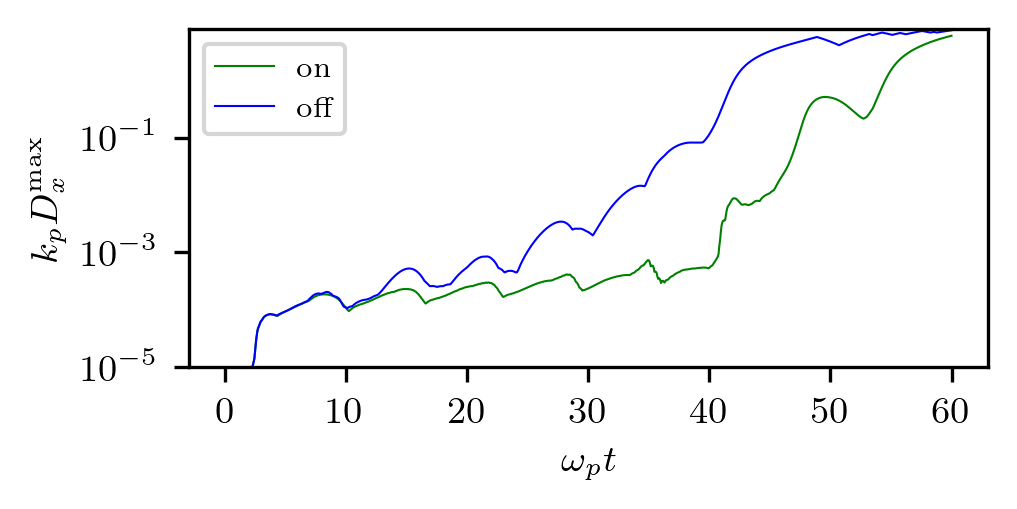

In [23]:
# It is assumed that the run with declustering is in folder 'on'
# It is assumed that the run without declustering is in folder 'off'

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc, rcParams

rc('text', usetex=True)
rcParams["font.family"] = "Times New Roman"
rcParams["font.size"] = 9
rc('legend', fontsize=7)
mm = 0.1/2.54

def nplot(file, color, txt=''):
    fxi = np.load(file + '/diagnostics/f_xi_00025.00.npz')
    plt.plot(-fxi['xi'], fxi['dx_chaotic_perp'], lw=0.5, color=color, label=txt)

fig = plt.figure(figsize=(83*mm, 40*mm), dpi=300)
nplot('./on', 'g', 'on')
nplot('./off', 'b', 'off')
# plt.xlim(0,150)
# plt.ylim(-0.01,0.22)
plt.ylim(1e-5,)
ax=plt.gca()
ax.set_yscale('log')
plt.xlabel(r'$\omega_{p} t$')
plt.ylabel(r'$k_p D_x^\mathrm{max}$')
plt.legend(ncol=1)

plt.tight_layout(pad=0.3)
plt.savefig('Dmax.png', format='png', dpi=300, bbox_inches='tight')

In [24]:
# This produces animations of electron density

import os
import imageio.v2 as imageio

def ani(figtype, dir):
    images = []
    files = sorted([i for i in os.listdir(dir + '/diagnostics') if (i.startswith(figtype) and (i.endswith('.jpg'))) ])
    for filename in files:
        images.append(imageio.imread(dir + '/diagnostics/' + filename))
    imageio.mimwrite(dir + '/' + figtype + '.gif', images, loop=0, fps=5)

ani('rho', 'on')
ani('rho', 'off')


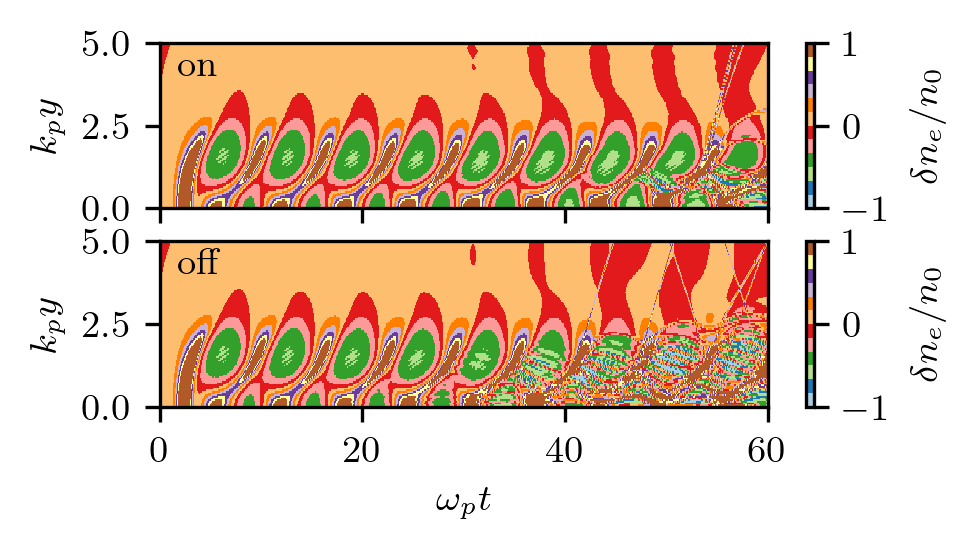

In [25]:
# Perturbation of the electron density

ampl = 1
def fragment(workdir, time=25):
    cmap = np.load(workdir + f'diagnostics/colormaps_{time:05d}.00.npz')
    ro = (cmap['rho'].T)
    xis = -cmap['xi']
    xs = cmap['transverse_grid']
    plt.pcolormesh(xis, xs, -ro, cmap='Paired', vmin=-ampl, vmax=ampl, rasterized=True)
    plt.colorbar(label=r'$\delta n_e / n_0$', orientation="vertical")
    plt.ylim(0,5)
    plt.xlim(0,60)
    plt.ylabel(r'$k_p y$')

fig = plt.figure(figsize=(83*mm, 40*mm), dpi=300)

plt.subplot(211)
fragment("on/")
ax=plt.gca()
ax.axes.xaxis.set_ticklabels([])
plt.text(0.03, 0.8, 'on', transform=ax.transAxes, c='k')

plt.subplot(212)
fragment("off/")
plt.xlabel(r'$\omega_p t$')
ax=plt.gca()
plt.text(0.03, 0.8, 'off', transform=ax.transAxes, c='k')

plt.savefig('ne.png',format='png', dpi=300, bbox_inches='tight')